# 2D Optical Kagome Superlattice Potential Calculation

This notebook calculates and visualizes a 2D optical kagome superlattice potential by evaluating a 3D superspace potential on a (111) cut. 

## Physics and Geometry
The potential is defined as:
$$ V(X_1, X_2, X_3) = \sum_{i=1}^{3} [V_1 \cos(X_i) + V_2 \cos(2X_i + \theta_i)] $$
where $X_i = k_i \cdot r + \phi_{\text{plane}}$ are the superspace coordinates for a 2D position $r = (x, y)$ on a plane translated by $\phi_{\text{plane}}$.

We use the fundamental wavevectors $K_1, K_2, K_3$ (corresponding to 1064 nm) from `E9_fn.E9_constants` as the base wavevectors $k_i$. The harmonic lattice corresponds to the 532 nm lattice ($k_{532} = 2 K_{1064}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from itertools import product, combinations
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Ensure the project root is in the path to allow importing E9_fn
# The script is located in root/projects/superlattice_translation/
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

import E9_fn.E9_constants as E9c

In [7]:
def calculate_kagome_superlattice(V1, V2, Theta, plane_offset = 0.0, x_lims = (-2e-6, 2e-6), y_lims = (-2e-6, 2e-6), res = 500):
    """
    Evaluates the 2D optical kagome superlattice potential on a grid.
    
    Args:
        V1 (float): Amplitude of the fundamental (1064 nm) lattice.
        V2 (float): Amplitude of the harmonic (532 nm) lattice.
        Theta (tuple): Phase shifts (theta_1, theta_2, theta_3).
        plane_offset (float): Offset for translating the (111) cut plane in superspace.
        x_lims (tuple): Range for x coordinates in meters.
        y_lims (tuple): Range for y coordinates in meters.
        res (int): Grid resolution.
        
    Returns:
        X, Y, V: Grid coordinates and calculated potential.
    """
    # 1. Fundamental wavevectors from E9_constants (1064 nm)
    K_vectors = [E9c.K1, E9c.K2, E9c.K3]
    
    # 2. Create vectorized 2D spatial grid
    x = np.linspace(x_lims[0], x_lims[1], res)
    y = np.linspace(y_lims[0], y_lims[1], res)
    X, Y = np.meshgrid(x, y)
    
    # Initialize potential array
    V = np.zeros_like(X)
    
    # 3. Vectorized calculation of the potential landscape
    # Formula: V = sum [ V1 * cos(Ki . r + offset) + V2 * cos(2 * (Ki . r + offset) + theta_i) ]
    # Adhering to strict operator spacing rules.
    for i in range(3):
        Ki = K_vectors[i]
        theta_i = Theta[i]
        
        # Dot product with plane translation: Xi = Ki_x * x + Ki_y * y + plane_offset
        Xi = Ki[0] * X + Ki[1] * Y + plane_offset
        
        # Accumulate the potential contribution from the i-th axis
        V = V + V1 * np.cos(Xi) + V2 * np.cos(2 * Xi + theta_i)
        
    return X, Y, V

def visualize_potential(X, Y, V, V1, V2, Theta, plane_offset):
    """
    Visualizes the potential using strict object-oriented Matplotlib.
    """
    # Create figure and axis objects
    fig, ax = plt.subplots(figsize = (10, 8))
    
    # Plot potential landscape with 'magma' colormap
    im = ax.pcolormesh(X * 1e6, Y * 1e6, V, cmap = 'viridis', shading = 'auto')
    
    # Apply formatting and labels
    ax.set_aspect('equal')
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    ax.set_title(f'2D Optical Kagome Superlattice Potential\n' + 
                 f'V1 = {V1}, V2 = {V2}, Theta = {Theta}, Plane Offset = {plane_offset}')
    
    # Add a colorbar
    cbar = fig.colorbar(im, ax = ax)
    cbar.set_label('Potential Energy (a.u.)')
    
    # Optimize layout and display
    plt.tight_layout()
    plt.show()

def visualize_superspace_plane(plane_offset = 0.0):
    """
    Visualizes the (111) plane cut in the 3D superspace using object-oriented Matplotlib.
    """
    # Create figure with 3D projection
    fig = plt.figure(figsize = (10, 8))
    ax = fig.add_subplot(111, projection = '3d')
    
    # Define bounding limits for the superspace axes
    lim = 2 * np.pi
    
    # Draw a bounding cube for visual perspective (preserving green color from user)
    r = [0, lim]
    for s, e in combinations(np.array(list(product(r, r, r))), 2):
        if np.sum(np.abs(s - e)) == r[1] - r[0]:
            ax.plot3D(*zip(s, e), color = "green", alpha = 0.5)
            
    # Add a transparent unit cell box [0, 2pi]^3
    # vertices of the cube
    v = np.array([
        [0, 0, 0], [lim, 0, 0], [lim, lim, 0], [0, lim, 0],
        [0, 0, lim], [lim, 0, lim], [lim, lim, lim], [0, lim, lim]
    ])
    # faces of the cube
    faces = [
        [v[0], v[1], v[2], v[3]], [v[4], v[5], v[6], v[7]], # bottom, top
        [v[0], v[1], v[5], v[4]], [v[2], v[3], v[7], v[6]], # front, back
        [v[0], v[3], v[7], v[4]], [v[1], v[2], v[6], v[5]]  # left, right
    ]
    poly = Poly3DCollection(faces, alpha = 0.1, facecolors = 'yellow', edgecolors = 'green')
    ax.add_collection3d(poly)

    # Draw the coordinate axes explicitly
    ax.plot([0, lim], [0, 0], [0, 0], 'k-', alpha = 0.5, linewidth = 2)
    ax.plot([0, 0], [0, lim], [0, 0], 'k-', alpha = 0.5, linewidth = 2)
    ax.plot([0, 0], [0, 0], [0, lim], 'k-', alpha = 0.5, linewidth = 2)
            
    # Label the points of intersection of the (111) plane with the axes
    p = 3 * plane_offset
    pts = np.array([[p, 0, 0], [0, p, 0], [0, 0, p]])
    for pt in pts:
        if 0 <= pt[0] <= lim and 0 <= pt[1] <= lim and 0 <= pt[2] <= lim:
            ax.scatter(pt[0], pt[1], pt[2], color = 'red', s = 50)
            ax.text(pt[0], pt[1], pt[2], f' ({pt[0]:.2f}, {pt[1]:.2f}, {pt[2]:.2f})', color = 'red')

    # Create the (111) plane: X1 + X2 + X3 = 3 * plane_offset
    x1 = np.linspace(0, lim, 10)
    x2 = np.linspace(0, lim, 10)
    X1, X2 = np.meshgrid(x1, x2)
    X3 = 3 * plane_offset - X1 - X2
    
    # Clip X3 values so the surface remains visually bounded by the cube
    X3[(X3 < 0) | (X3 > lim)] = np.nan
    
    # Plot the translucent cutting plane surface
    ax.plot_surface(X1, X2, X3, alpha = 0.5, color = 'cyan', edgecolor = 'none')
    
    # Final formatting
    ax.set_xlim([0, lim])
    ax.set_ylim([0, lim])
    ax.set_zlim([0, lim])
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title(f'Superspace (111) Cut Plane\\n$X_1 + X_2 + X_3 = {3 * plane_offset:.2f}$')
    
    plt.tight_layout()
    plt.show()

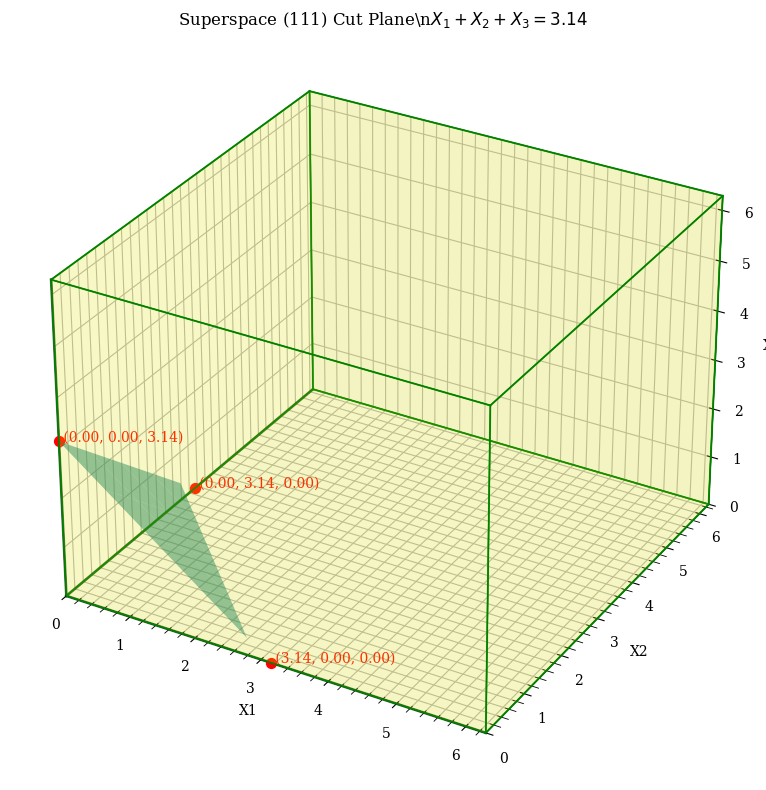

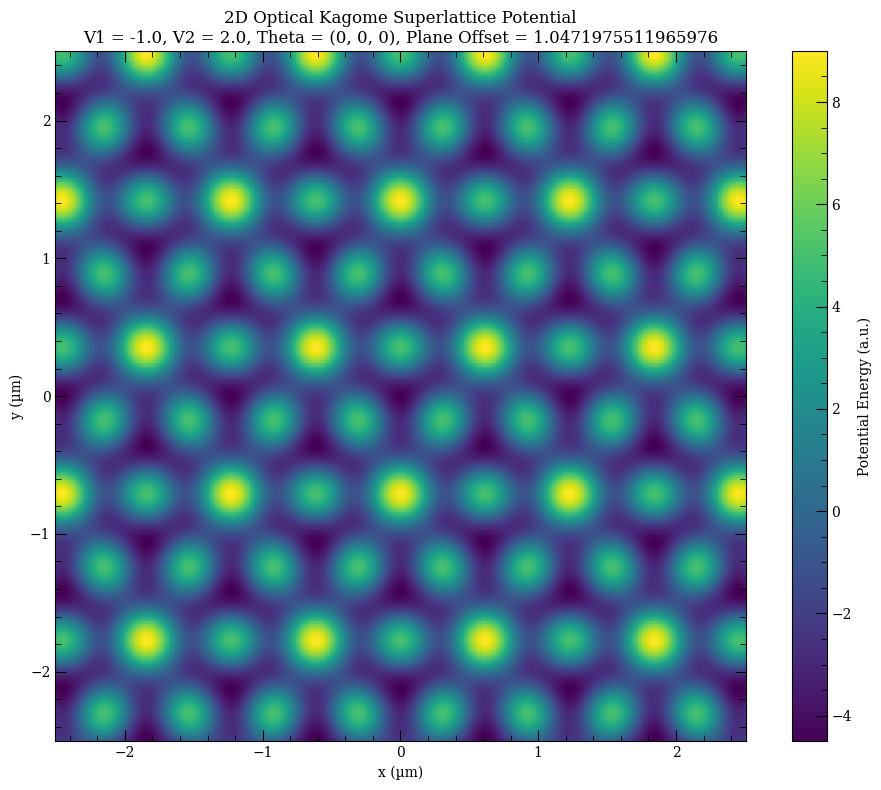

In [18]:
# Example execution
if __name__ == "__main__":
    # Define parameters for the potential
    V_fund = -1.0
    V_harm = 2.
    Phase_shifts = (0, 0, 0)
    # Phase_shifts = (np.pi / 2, np.pi / 2, np.pi / 2)
    Plane_offset = np.pi / 3  # Translation of the plane along the [111] diagonal
    
    # Visualize the 3D superspace cut plane
    visualize_superspace_plane(Plane_offset)
    
    # Calculate the potential landscape on the translated plane
    X_grid, Y_grid, Potential = calculate_kagome_superlattice(
        V_fund, V_harm, Phase_shifts, plane_offset = Plane_offset,
        x_lims = (-2.5e-6, 2.5e-6), 
        y_lims = (-2.5e-6, 2.5e-6)
    )
    
    # Render the 2D potential visualization
    visualize_potential(X_grid, Y_grid, Potential, V_fund, V_harm, Phase_shifts, Plane_offset)